# Relational Graph Extraction

This notebook orchestrates the full pipeline to extract characters and relationships
from a novel and build a relational graph.

The pipeline is configured via `book_config.json` which specifies the book title, author,
and character groups. This makes the pipeline reusable for any novel.

**Steps:**
1. Split text into chapters
2. Extract characters from each chapter (GPT-4o)
3. Merge/deduplicate into canonical character list (GPT-4o)
4. Extract relationship passages from text (GPT-4o)
5. Analyze passages into structured relationships (GPT-4o)
5b. Validate & clean relationships (o3-mini)
6. Build NetworkX graph
7. Visualize family trees with Graphviz

## 0. Setup

In [ ]:
# Install dependencies (uncomment on Colab)
# !pip install openai python-dotenv networkx pygraphviz matplotlib
# On Colab, you may also need:
# !apt-get install -y graphviz libgraphviz-dev
# !pip install pygraphviz

In [ ]:
import json
from pathlib import Path

# Create output directories
Path("data/cache").mkdir(parents=True, exist_ok=True)
Path("output").mkdir(parents=True, exist_ok=True)

# Load book configuration
BOOK_CONFIG = "book_config.json"
config = json.loads(Path(BOOK_CONFIG).read_text(encoding="utf-8"))
print(f"Book: {config['title']} by {config['author']}")
print(f"Groups: {config.get('groups', [])}")
print("Directories ready.")

## 1. Split text into chapters

In [ ]:
from src.split_chapters import main as split_main

chapters = split_main("La_Fortune_des_Rougon.txt", "data/chapters.json")

In [ ]:
# Inspect: preview first 200 chars of each chapter
for key, text in chapters.items():
    print(f"\n=== {key} ===")
    print(text[:200] + "...")

## 2. Extract characters from each chapter

In [ ]:
from src.extract_characters import main as extract_chars_main

raw_characters = extract_chars_main("data/chapters.json", "data/raw_characters.json",
                                    book_config_path=BOOK_CONFIG)

In [ ]:
# Inspect raw characters per chapter
for key, chars in raw_characters.items():
    names = [c["name"] for c in chars]
    print(f"{key}: {names}")

## 3. Merge into canonical character list

In [ ]:
from src.merge_characters import main as merge_main

characters = merge_main("data/raw_characters.json", "data/characters.json",
                        book_config_path=BOOK_CONFIG)

In [ ]:
# Inspect canonical characters
for c in characters:
    group = c.get('group', c.get('family_branch', 'other'))
    print(f"{c['canonical_name']:25s} [{group:8s}] aliases={c['aliases']}")

## 4. Extract relationship passages

In [ ]:
from src.extract_passages import main as extract_passages_main

passages = extract_passages_main(
    "data/chapters.json",
    "data/characters.json",
    "data/passages.json",
    book_config_path=BOOK_CONFIG,
)

In [ ]:
# Inspect extracted passages
for key, plist in passages.items():
    print(f"\n=== {key} ({len(plist)} passages) ===")
    for p in plist[:3]:
        print(f"  [{p.get('relationship_hint', '?')}] {p['text'][:100]}...")
    if len(plist) > 3:
        print(f"  ... and {len(plist) - 3} more")

## 5. Analyze passages into structured relationships

In [ ]:
from src.extract_relationships import main as extract_rels_main

relationships = extract_rels_main(
    "data/passages.json",
    "data/characters.json",
    "data/relationships.json",
    book_config_path=BOOK_CONFIG,
)

In [ ]:
# Inspect relationships
for r in relationships:
    arrow = "->" if r["directed"] else "--"
    print(f"{r['source']:25s} {arrow} {r['target']:25s} [{r['type']}] conf={r['confidence']}")

## 5b. Validate & clean relationships (o3-mini)

Uses the o3-mini reasoning model to validate relationship directions and types,
remove duplicates, and fix any inconsistencies.

In [ ]:
from src.clean_relationships import main as clean_main

clean_relationships = clean_main(
    "data/relationships.json",
    "data/characters.json",
    "data/relationships_clean.json",
)

In [ ]:
# Inspect cleaned relationships
print(f"Raw: {len(relationships)} edges -> Clean: {len(clean_relationships)} edges\n")
for r in clean_relationships:
    arrow = "->" if r["directed"] else "--"
    print(f"{r['source']:25s} {arrow} {r['target']:25s} [{r['type']}]")

## 6. Build graph

In [1]:
from src.build_graph import main as build_main

G = build_main("data/characters.json", "data/relationships_clean.json", "output/graph.graphml")

Graph built: 35 nodes, 109 edges


## 7. Visualize

In [2]:
from src.visualize import main as viz_main

viz_main("output/graph.graphml", "output", book_config_path=BOOK_CONFIG)

NameError: name 'BOOK_CONFIG' is not defined


--- family_tree_all ---


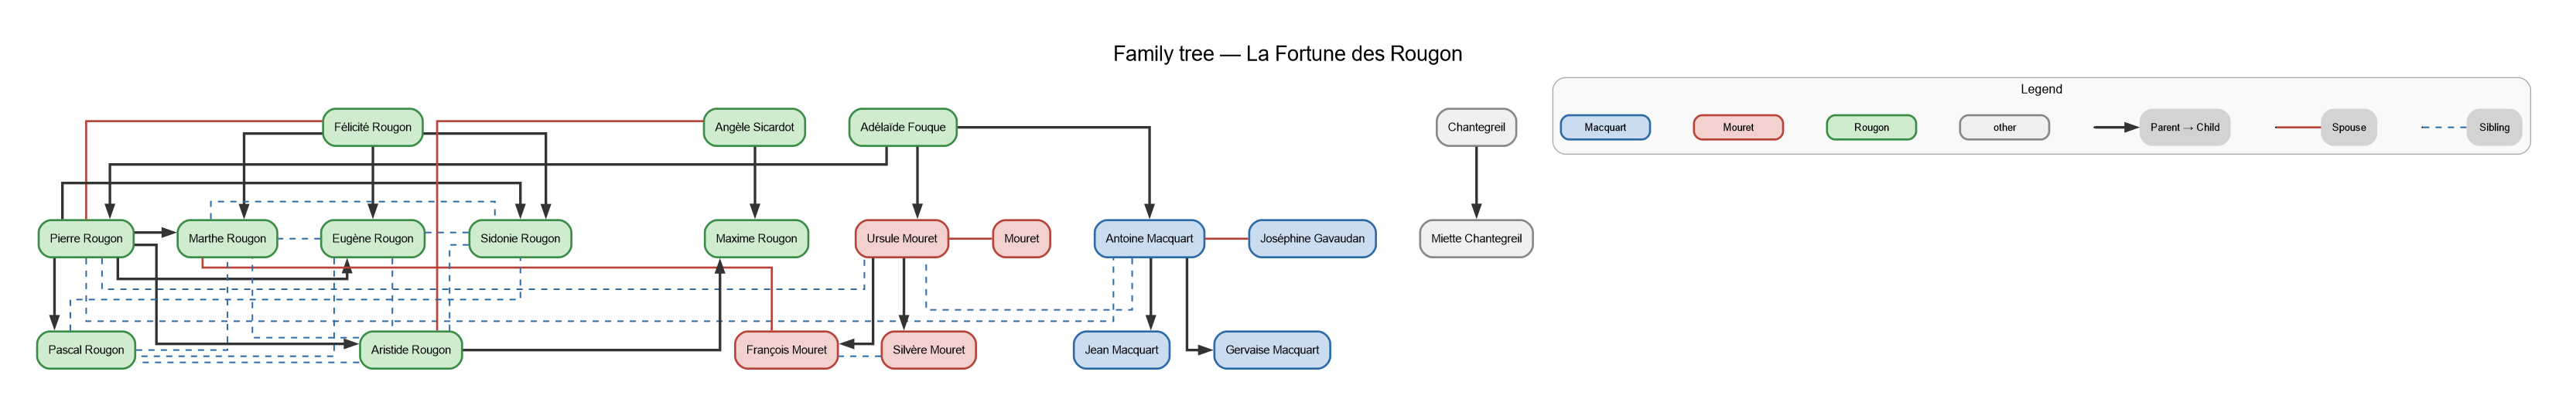


--- family_tree_macquart ---


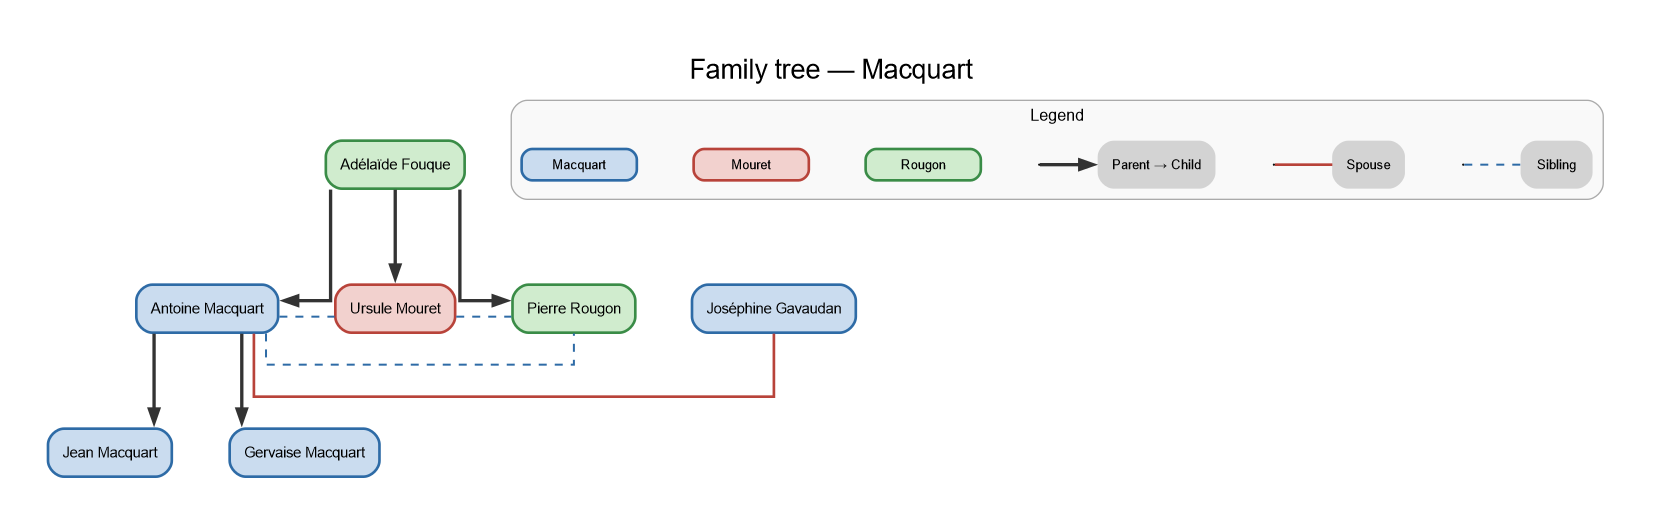


--- family_tree_mouret ---


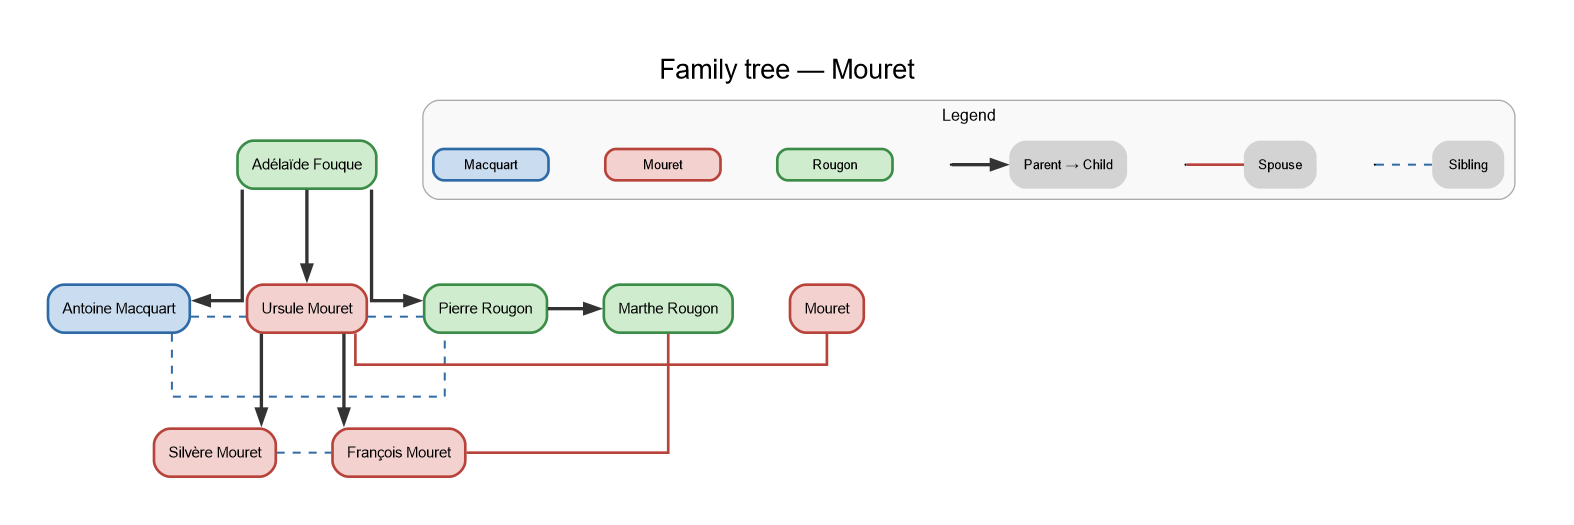


--- family_tree_rougon ---


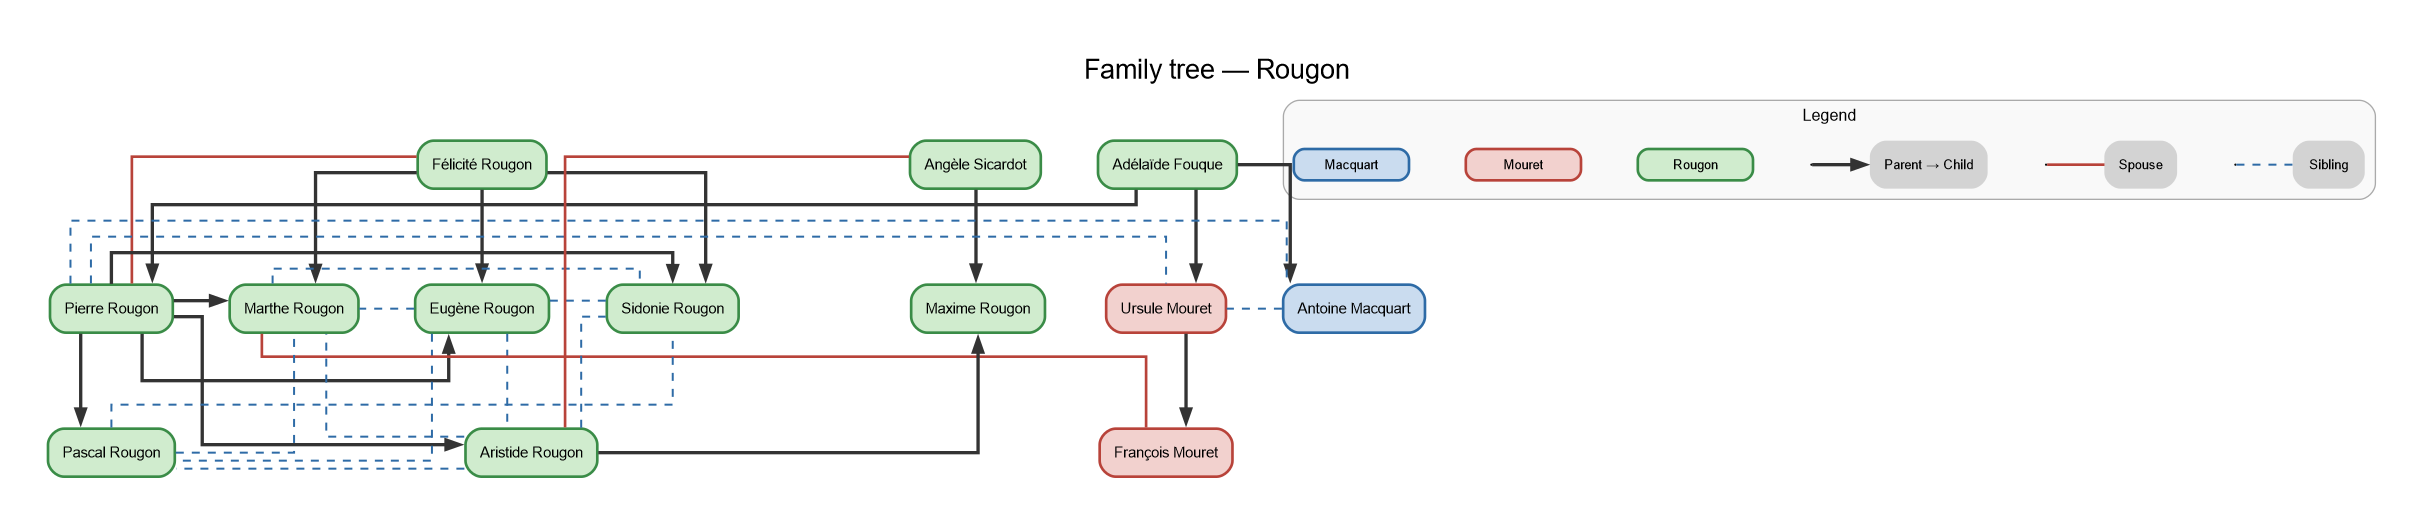

In [3]:
from IPython.display import Image, display
from pathlib import Path

for img in sorted(Path("output").glob("family_tree_*.png")):
    print(f"\n--- {img.stem} ---")
    display(Image(filename=str(img)))